# Gamma-Ray Source Population & Peak Detection

**Overview:**  
This notebook simulates a Galactic gamma-ray source population using gammapop, creates sky maps, applies angular resolution (PSF),

## 1. Create Population Model
Create a spatial model (spiral arms + bar/bulge) and source property models (luminosity and radius distributions).

In [1]:
# Imports
import sys
from pathlib import Path

# Ensure local gammapop package is on path (gammapop_student/gammapop)
_repo = Path.cwd().resolve()
if _repo.name == "peak_finder_analysis":
    _repo = _repo.parent
_gammapop_student = _repo / "gammapop_student"
if _gammapop_student.is_dir() and str(_gammapop_student) not in sys.path:
    sys.path.insert(0, str(_gammapop_student))

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord, Angle
from astropy.convolution import Gaussian2DKernel, convolve
from astropy.table import Table

# Gammapop imports
from gammapop.model import PopulationModel
from gammapop.model.spatial import (
    CompoundSpatialModel,
    ReidSpatialModel, 
    SormaniSpatialModel
)
from gammapop.model.source import (
    IndependentSourcePropertyModel,
    PowerLawModel
)
from gammapop.survey import HGPS
# Reload hess module so edits to hess.py are picked up without a kernel restart
import importlib, gammapop.survey.hess as _hess_mod
importlib.reload(_hess_mod)
from gammapop.survey.hess import HGPS  # re-import after reload
from gammapop.utils.skymap import get_observation_window, get_sky_map
from gammapop.utils.visualise import plot_sky_map

# Create a population model

# Gammapy imports
from gammapy.maps import Map, WcsGeom
from gammapy.estimators import FluxMaps
from gammapy.estimators.utils import find_peaks_in_flux_map

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

# Spatial distribution: compound model with spiral arms (Reid) + bar/bulge (Sormani)
# 35% of sources in the bar/bulge region
spatial_model = CompoundSpatialModel(
    disc=ReidSpatialModel(), 
    bar=SormaniSpatialModel(), 
    fraction_bar=0.35
)

# Source property models: power law distributions for luminosity and radius
luminosity_model = PowerLawModel(
    "luminosity", 
    alpha=-1.5, 
    xmin=1e32 / u.s, 
    xmax=1e35 / u.s
)

radius_model = PowerLawModel(
    "radius", 
    alpha=-0.5, 
    xmin=1.0 * u.pc, 
    xmax=100.0 * u.pc
)

# Combine into complete population model
population_model = PopulationModel(
    spatial_model=spatial_model,
    source_model=IndependentSourcePropertyModel(
        luminosity_model=luminosity_model,
        radius_model=radius_model,
    ),
)

print(f"   Spatial Model: Reid spiral arms + Sormani bar/bulge (35% bar fraction)")
print(f"   Luminosity Model: power-law with α = -1.5, range [1e32, 1e35] s⁻¹")
print(f"   Radius Model: power-law with α = -0.5, range [1, 100] pc")

/opt/miniconda3/envs/gammapop/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


   Spatial Model: Reid spiral arms + Sormani bar/bulge (35% bar fraction)
   Luminosity Model: power-law with α = -1.5, range [1e32, 1e35] s⁻¹
   Radius Model: power-law with α = -0.5, range [1, 100] pc


## 2. Simulate Source Population

Generate a population of gamma-ray sources following the defined distributions.

We now create a flux map with ALL sources (no detectability filtering).

This allows us to visualize the complete simulated population before applying any detection threshold. The detectability criterion will be applied in later steps directly to the flux map with assumptions about source sizes.

In [2]:
# Simulate a population of 1000 sources
n_sources = 1000
population = population_model.get_sample(n_sources)

print(f"Simulated {len(population)} sources")

# Reload hess.py before creating the survey so any code changes are picked up
import importlib, gammapop.survey.hess as _hess_mod
importlib.reload(_hess_mod)
from gammapop.survey.hess import HGPS

# Load HGPS survey (for future use in later steps)
survey = HGPS()

# Use ALL sources without detectability filtering
print(f"Using ALL {len(population)} simulated sources for flux map generation")
print(f"(No detectability filter applied)")
print(f"\nSource population statistics:")
print(f"  Flux range: {population['flux'].min():.2e} - {population['flux'].max():.2e} cm^-2 s^-1")
print(f"  Extent range: {population['extent'].min():.3f} - {population['extent'].max():.3f}")

population[:5]

Simulated 1000 sources
Using ALL 1000 simulated sources for flux map generation
(No detectability filter applied)

Source population statistics:
  Flux range: 2.50e-15 1 / (s cm2) - 6.11e-10 1 / (s cm2) cm^-2 s^-1
  Extent range: 0.004 deg - 4.829 deg


coordinate,luminosity,radius,flux,extent
"deg,deg,kpc",1 / s,pc,1 / (s cm2),deg
SkyCoord,float32,float32,float32,float32
"351.51718216304914,0.08650024181686096,11.328022965005028",3.4553018731646994e+32,1.6195095777511597,2.2504366060005672e-14,0.008191284723579884
"25.80239369517311,-0.02626079414653639,8.5160723421621",1.1545175811755122e+32,2.044757127761841,1.3304878439214171e-14,0.013757040724158287
"336.0110639403592,0.05825848556327308,8.855212796334577",1.9006474476566786e+32,50.80680465698242,2.0257816149386876e-14,0.32873106002807617
"10.435225851902526,0.1492969954538398,11.310109873269736",2.1074437837942523e+32,42.71564483642578,1.3769285428370023e-14,0.21639175713062286
"13.280604810622584,-0.05109727029289761,4.959124714645801",8.659441639827856e+32,62.12656021118164,2.942855106737724e-13,0.7177483439445496


## 3. Define Observation Window & Create Sky Map
Define the sky region (lon/lat ranges), energy range, and resolution. Then generate the sky map using gammapop's utilities.

### Visualize Original Sky Map (Before PSF)

Display the gamma-ray sky map generated from the simulated population.

Observation window defined:
  Energy: 1.0 TeV - 10.0 TeV
  Longitude: -100.0 deg to 70.0 deg
  Latitude: -5.0 deg to 5.0 deg
  Resolution: 0.1 deg


100%|██████████| 1000/1000 [00:14<00:00, 68.71it/s]
/Users/infantronald/M.Sc. Astrophysics/Master's Thesis/gamma_confusion/gammapop/utils/visualise.py:112: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.89)



Sky map created!
  Map type: <class 'gammapy.maps.wcs.ndmap.WcsNDMap'>
  Map shape: (1, np.int64(100), np.int64(1700))


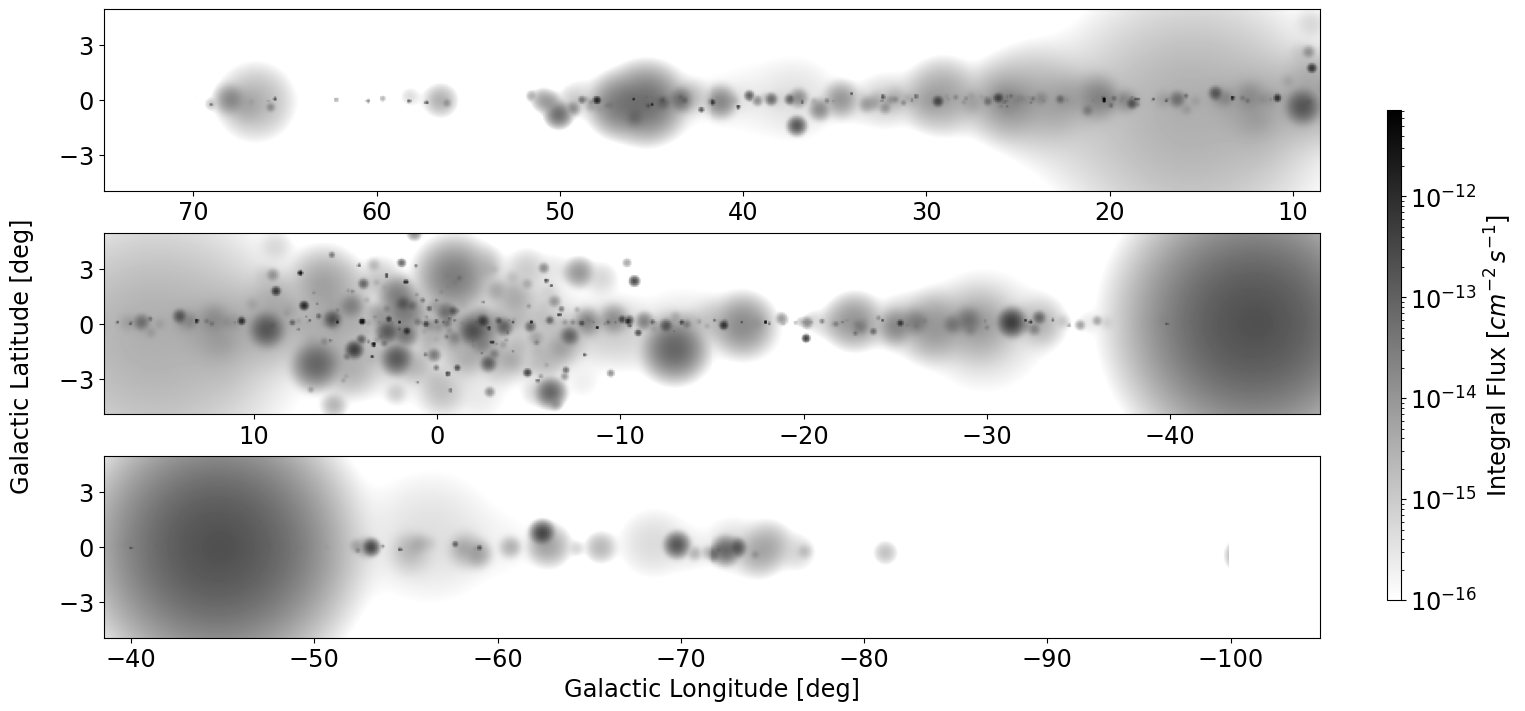

In [3]:
# Define observation window
energy_range = [1.0, 10.0] * u.TeV  # Energy range: 1-10 TeV (typical for HGPS)
lon_range = Angle([-100, 70], u.deg).wrap_at(180 * u.deg)  # Galactic longitude
lat_range = Angle([-5, 5], u.deg)  # Galactic latitude
resolution = 0.1 * u.deg  # Map resolution (pixel size)

observation_window = get_observation_window(
    energy_range, lon_range, lat_range, resolution
)

print(f"Observation window defined:")
print(f"  Energy: {energy_range[0]} - {energy_range[1]}")
print(f"  Longitude: {lon_range[0]:.1f} to {lon_range[1]:.1f}")
print(f"  Latitude: {lat_range[0]} to {lat_range[1]}")
print(f"  Resolution: {resolution}")

# Generate sky map from ALL sources (Step 1 modification)
sky_map = get_sky_map(population, observation_window)

print(f"\nSky map created!")
print(f"  Map type: {type(sky_map)}")
print(f"  Map shape: {sky_map.geom.data_shape}")

# Use gammapop's built-in visualization
plot_sky_map(sky_map)

## 4. Apply Angular Resolution (PSF Convolution)

**Angular Resolution:** 0.1° FWHM Gaussian PSF  (Fixed Angular Resolution for now; Using HESS Resolution) - Point 

**Conversion:** FWHM = 2.355 × σ → σ = FWHM / 2.355 ≈ 0.0425° (Full Width at Half Maximum)

In [4]:
# Angular resolution parameters
fwhm_deg = 0.1  # degrees
sigma_deg = fwhm_deg / 2.355

# Get pixel size from the sky map geometry
pixel_size = sky_map.geom.pixel_scales.mean().to('deg').value
sigma_pix = sigma_deg / pixel_size

print(f"Sky map shape: {sky_map.data.shape}")
print(f"Sky map ndim: {sky_map.data.ndim}")
print(f"PSF FWHM: {fwhm_deg}°")
print(f"PSF sigma: {sigma_deg:.4f}° = {sigma_pix:.2f} pixels")
print(f"Pixel size: {pixel_size:.4f}°")

# Create Gaussian PSF kernel
psf_kernel = Gaussian2DKernel(x_stddev=sigma_pix, y_stddev=sigma_pix)

# Apply convolution - handle different dimensionalities
if sky_map.data.ndim == 2:
    # 2D map - direct convolution
    flux_data_convolved = convolve(sky_map.data, psf_kernel, boundary='extend')
elif sky_map.data.ndim == 3:
    # 3D map (e.g., with energy axis) - convolve only spatial dimensions
    # Sky map is typically [energy, lat, lon] or similar
    flux_data_convolved = np.zeros_like(sky_map.data)
    for i in range(sky_map.data.shape[0]):
        flux_data_convolved[i] = convolve(sky_map.data[i], psf_kernel, boundary='extend')
else:
    raise ValueError(f"Unexpected sky map dimensions: {sky_map.data.ndim}")

# Create PSF-convolved map
sky_map_psf = Map.from_geom(sky_map.geom, data=flux_data_convolved, unit=sky_map.unit)

# 2D flux map for detectability and peak-finding (same as PSF map; sum over energy if 3D)
flux_map_2d = sky_map_psf if sky_map_psf.data.ndim == 2 else sky_map_psf.sum_over_axes()

print(f"\nOriginal sky map: max={sky_map.data.max():.2e}, min={sky_map.data.min():.2e}")
print(f"After PSF: max={sky_map_psf.data.max():.2e}, min={sky_map_psf.data.min():.2e}")

Sky map shape: (1, 100, 1700)
Sky map ndim: 3
PSF FWHM: 0.1°
PSF sigma: 0.0425° = 0.42 pixels
Pixel size: 0.1000°

Original sky map: max=7.16e-12, min=2.05e-38
After PSF: max=5.90e-12, min=2.09e-38


## 5. Apply Detection Threshold to Flux Map

Apply detection thresholds directly to the flux map with different assumed source sizes.

Since a flux map doesn't have individual source sizes for each pixel, we test several assumptions:
- Point-like sources (0.0°)
- Extended sources: 0.1°, 0.2°, 0.4°

For each assumption, we:
1. Get the flux threshold from the survey sensitivity
2. Apply it to create a binary detectability map
3. Visualize which regions would be detectable

In [5]:
# Define test source extensions
test_extensions = [0.0, 0.1, 0.2, 0.4] * u.deg

# For each assumed source extension, determine which pixels are detectable
# We need to check detectability at each pixel position

# Get the sky coordinates for each pixel in our map
from astropy.coordinates import SkyCoord


# Create coordinate grid from our flux map
lon_grid, lat_grid = flux_map_2d.geom.get_coord().skycoord.galactic.l, \
                     flux_map_2d.geom.get_coord().skycoord.galactic.b

# Get flux values at each pixel
flux_values = flux_map_2d.data

# Store results for each extension assumption
detectability_maps = {}
detectable_pixel_counts = {}

print("Processing each source size assumption...\n")

for ext in test_extensions:
    print(f"Source extension: {ext:.1f}")
    
    # Create arrays to store results
    is_detectable = np.zeros_like(flux_values, dtype=bool)
    
    # Flatten arrays for easier processing
    lon_flat = lon_grid.flatten()
    lat_flat = lat_grid.flatten()
    flux_flat = flux_values.flatten()
    
    # Create SkyCoord objects for all positions
    coords = SkyCoord(lon_flat, lat_flat, frame='galactic', unit='deg')
    
    # Check detectability for all pixels at once
    # The survey.is_detectable expects coordinate, flux, and extent arrays
    detectable_flat = survey.is_detectable(
        coords,
        flux_flat * flux_map_2d.unit,
        np.full_like(flux_flat, ext.value) * u.deg
    )
    
    # Reshape back to 2D
    is_detectable = detectable_flat.reshape(flux_values.shape)
    
    # Store results
    detectability_maps[ext.value] = is_detectable
    n_detectable = np.sum(is_detectable)
    detectable_pixel_counts[ext.value] = n_detectable
    
    print(f"  Detectable pixels: {n_detectable} / {flux_values.size} "
          f"({100 * n_detectable / flux_values.size:.2f}%)")

Processing each source size assumption...

Source extension: 0.0 deg
  Detectable pixels: 75 / 170000 (0.04%)
Source extension: 0.1 deg
  Detectable pixels: 37 / 170000 (0.02%)
Source extension: 0.2 deg
  Detectable pixels: 21 / 170000 (0.01%)
Source extension: 0.4 deg
  Detectable pixels: 7 / 170000 (0.00%)


## 6. Creating Thresholded Flux Maps

The actual flux values only for detectable regions.

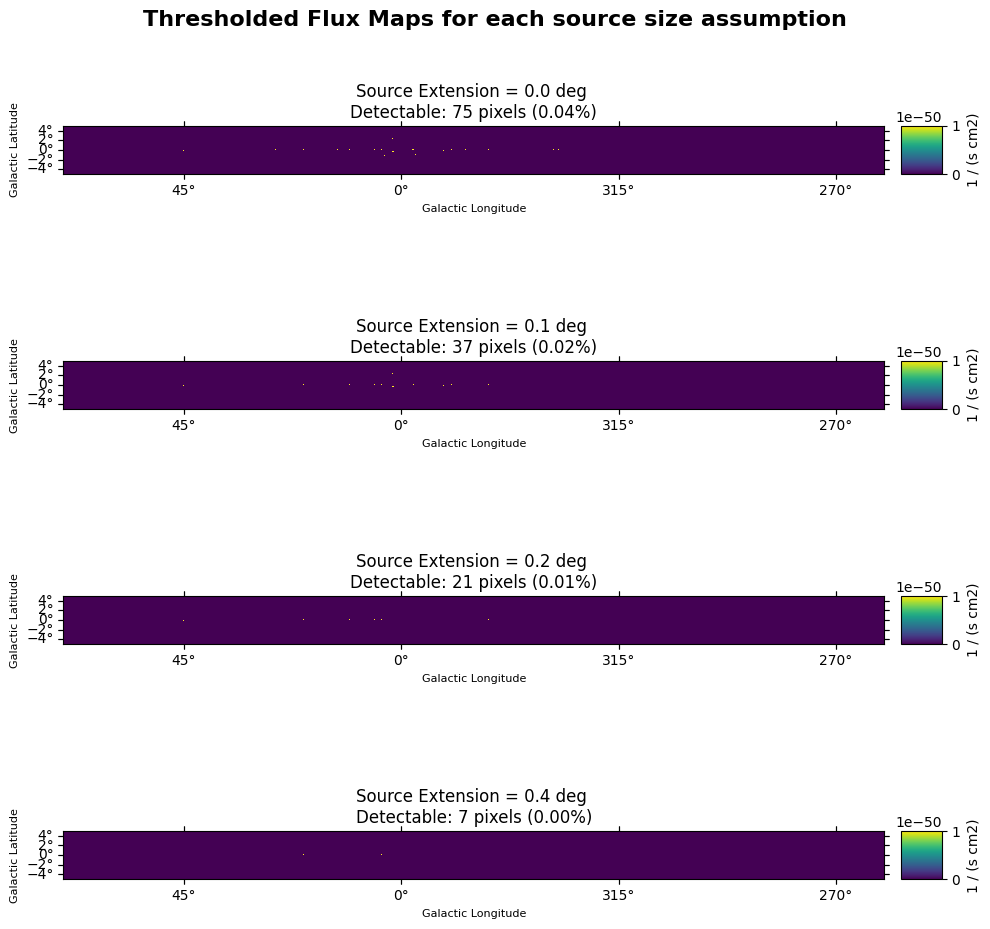

In [6]:
# Create thresholded flux maps (set non-detectable pixels to zero)
thresholded_flux_maps = {}

for ext in test_extensions:
    # Apply mask: keep flux only where detectable
    thresholded_flux = flux_values.copy()
    thresholded_flux[~detectability_maps[ext.value]] = 0
    
    thresholded_flux_maps[ext.value] = Map.from_geom(
        flux_map_2d.geom,
        data=thresholded_flux,
        unit=flux_map_2d.unit
    )

# Visualize thresholded flux maps in 2x2 grid
fig, axes = plt.subplots(4, 1, figsize=(10, 10),
                        subplot_kw={'projection': flux_map_2d.geom.wcs})
axes = axes.flatten()

# Plot each extension
for idx, ext in enumerate(test_extensions):
    ax = axes[idx]
    
    # Plot thresholded flux
    #thresholded_flux_maps[ext.value].plot(ax=ax, add_cbar=True, cmap='viridis')

    thresholded_flux_maps[ext.value].plot(
    ax=ax, add_cbar=True, cmap='viridis',
    vmin=0, vmax=1e-50)  # set vmax to a value that fits your flux units
    
    n_detect = detectable_pixel_counts[ext.value]
    pct = 100 * n_detect / flux_values.size
    
    # Set title for each subplot
    ax.set_title(f'Source Extension = {ext:.1f} \n'
                f'Detectable: {n_detect} pixels ({pct:.2f}%)',
                fontsize=12, fontweight='light')
    
    ax.set_xlabel('Galactic Longitude', fontsize=8)
    ax.set_ylabel('Galactic Latitude', fontsize=8)

    #ax.set_xlim(-180, 180)   # full longitude
    #ax.set_ylim(-10, 10)     # latitude ±10 deg; adjust as needed

plt.suptitle('Thresholded Flux Maps for each source size assumption', 
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 6a. Creating Sky Maps from the thresholded flux maps
The Map will be using the already built 'threshold_flux_maps'

Created 4 thresholded sky maps.

Source Extension = 0.0 deg
Detectable: 75 pixels (0.04%)



/Users/infantronald/M.Sc. Astrophysics/Master's Thesis/gamma_confusion/gammapop/utils/visualise.py:112: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.89)


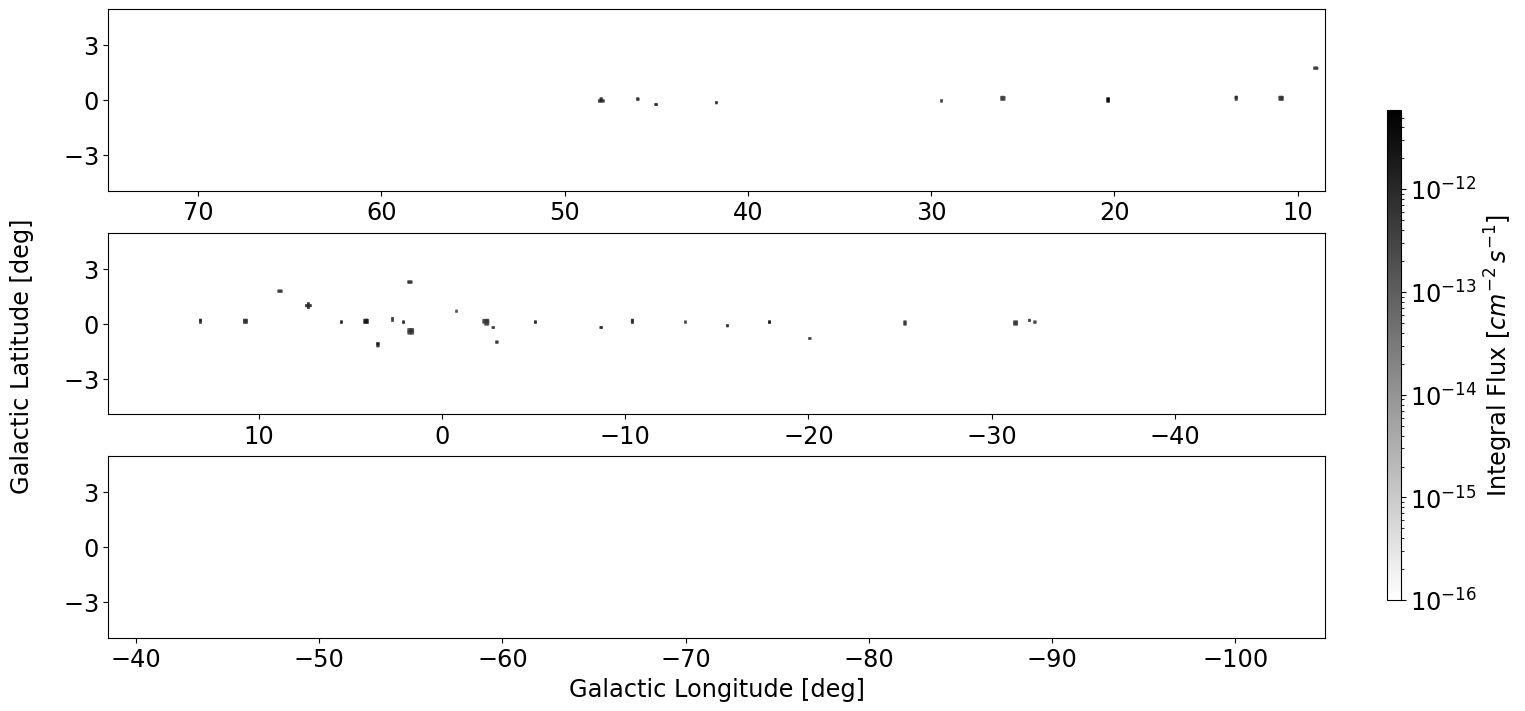

Source Extension = 0.1 deg
Detectable: 37 pixels (0.02%)



/Users/infantronald/M.Sc. Astrophysics/Master's Thesis/gamma_confusion/gammapop/utils/visualise.py:112: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.89)


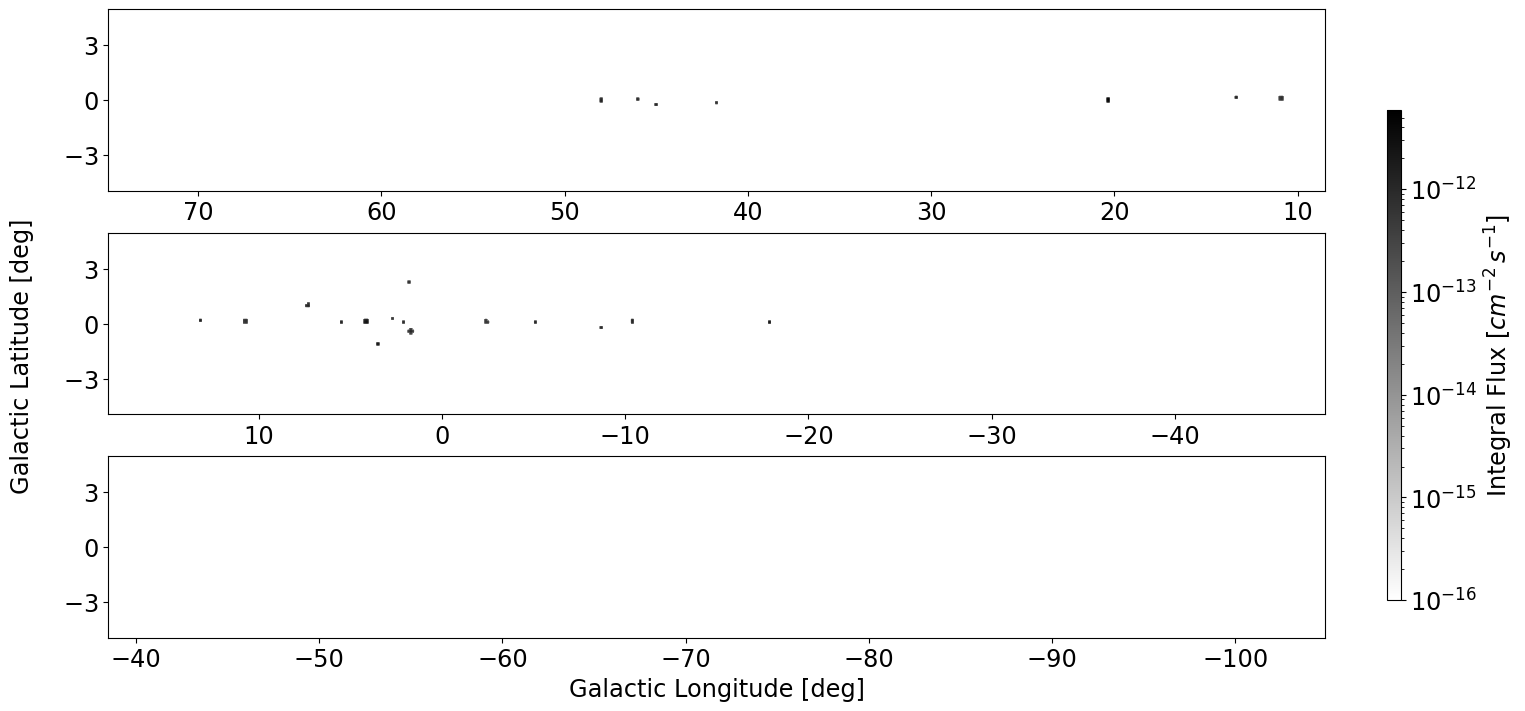

Source Extension = 0.2 deg
Detectable: 21 pixels (0.01%)



/Users/infantronald/M.Sc. Astrophysics/Master's Thesis/gamma_confusion/gammapop/utils/visualise.py:112: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.89)


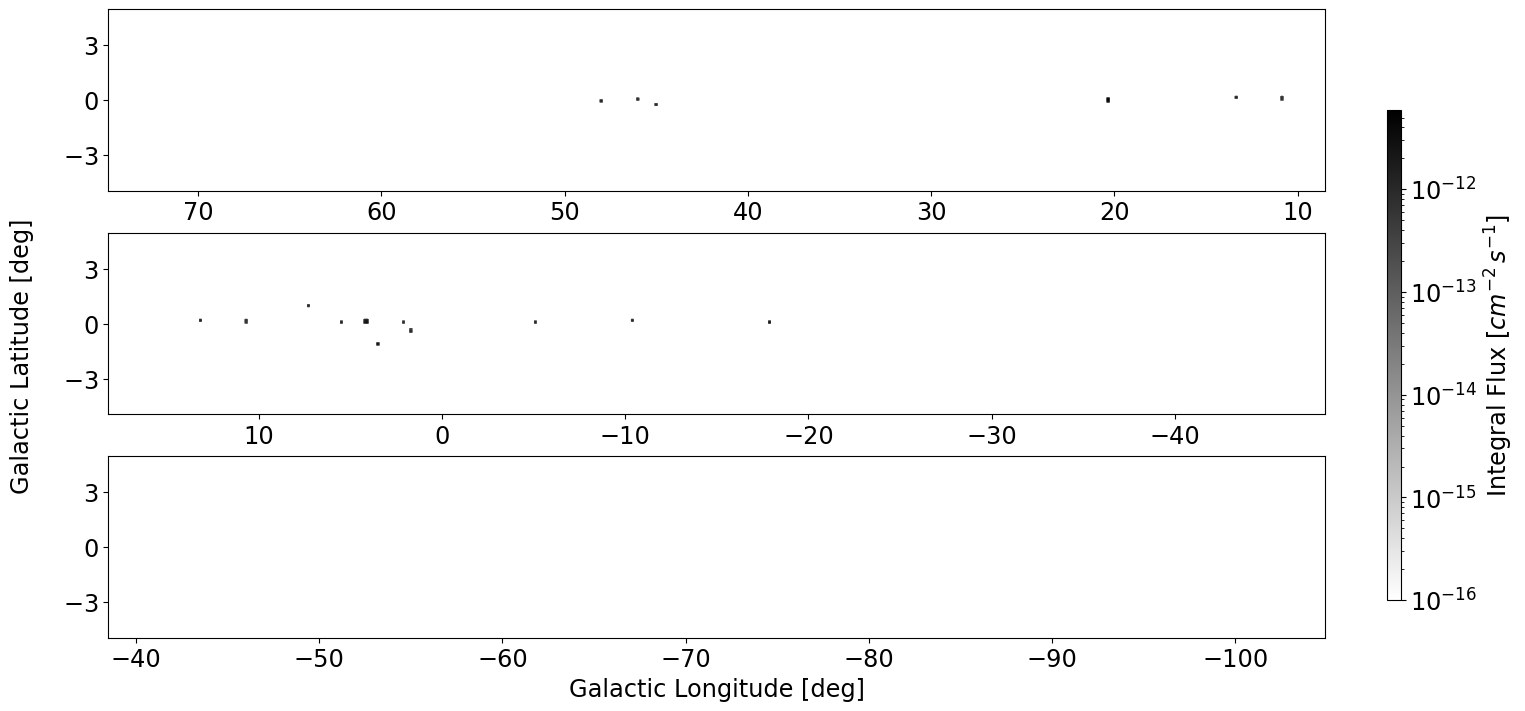

Source Extension = 0.4 deg
Detectable: 7 pixels (0.00%)



/Users/infantronald/M.Sc. Astrophysics/Master's Thesis/gamma_confusion/gammapop/utils/visualise.py:112: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.89)


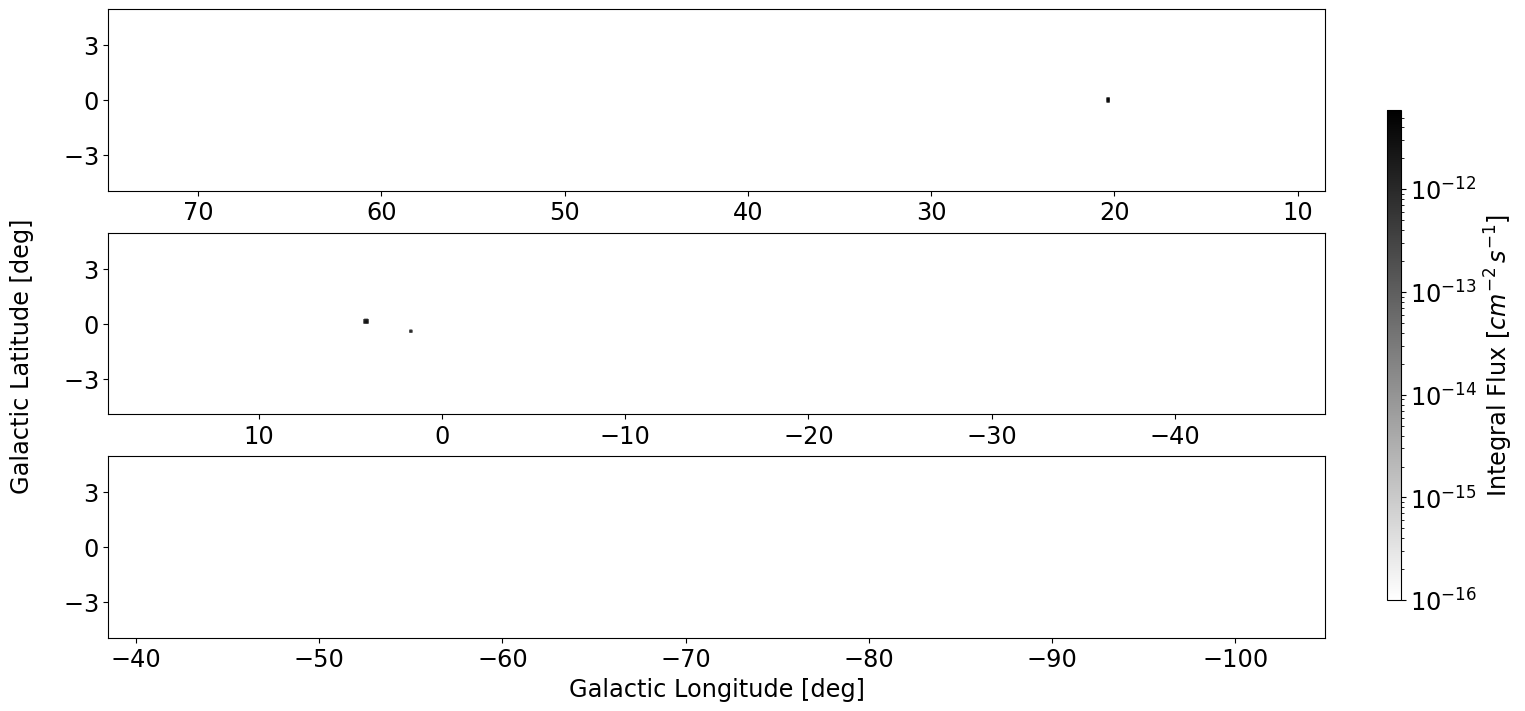

In [16]:
thresholded_sky_maps = {}

for ext in test_extensions:
    ext_key = ext.value
    m = thresholded_flux_maps[ext_key]

    # Ensure 2D map for plotting
    if len(m.geom.axes) > 0:
        m2d = m.sum_over_axes()
    else:
        m2d = m.copy()

    thresholded_sky_maps[ext_key] = m2d

print(f"Created {len(thresholded_sky_maps)} thresholded sky maps.\n")

# Plot each thresholded sky map using gammapop's built-in visualization
for ext in test_extensions:
    ext_key = ext.value
    sky_m = thresholded_sky_maps[ext_key]

    n_detect = detectable_pixel_counts[ext_key]
    pct = 100 * n_detect / sky_m.data.size

    print(f"Source Extension = {ext:.1f}")
    print(f"Detectable: {n_detect} pixels ({pct:.2f}%)\n")

    # Use gammapop's plot_sky_map (same style as Cell 6 output)
    plot_sky_map(sky_m)
    plt.show()

## 7. Comparison across Source Size Assumptions

### Key observations:
  - Larger assumed extensions → easier detection (more pixels above threshold)
  - Detection threshold depends strongly on source size assumption

Future:
 - Should check for 0.01 - 0.001 extension

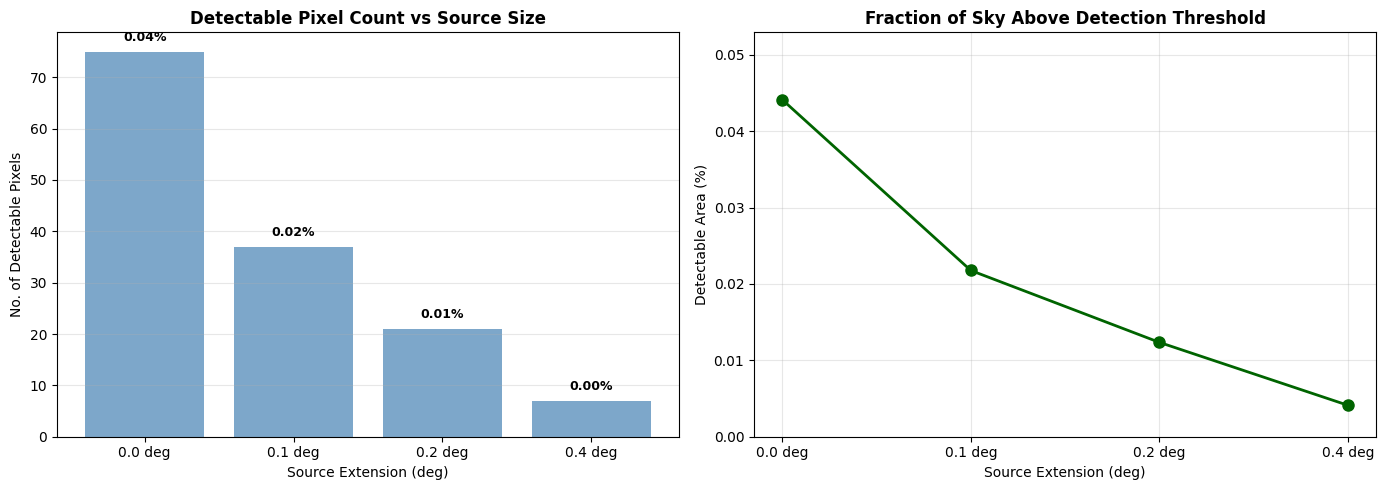

Extension (deg)      Detectable Pixels    Percentage     
------------------------------------------------------------
0.0                  75                   0.04           %
0.1                  37                   0.02           %
0.2                  21                   0.01           %
0.4                  7                    0.00           %


In [8]:
# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of detectable pixel counts
extensions_labels = [f"{ext:.1f}" for ext in test_extensions]
counts = [detectable_pixel_counts[ext.value] for ext in test_extensions]
percentages = [100 * c / flux_values.size for c in counts]

ax1.bar(extensions_labels, counts, color='steelblue', alpha=0.7)
ax1.set_xlabel('Source Extension (deg)', fontsize=10)
ax1.set_ylabel('No. of Detectable Pixels', fontsize=10)
ax1.set_title('Detectable Pixel Count vs Source Size', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for i, (count, pct) in enumerate(zip(counts, percentages)):
    ax1.text(i, count + max(counts)*0.02, f'{pct:.2f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Percentage plot
ax2.plot(extensions_labels, percentages, marker='o', markersize=8,
         linewidth=2, color='darkgreen')
ax2.set_xlabel('Source Extension (deg)', fontsize=10)
ax2.set_ylabel('Detectable Area (%)', fontsize=10)
ax2.set_title('Fraction of Sky Above Detection Threshold', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.set_ylim(0, max(percentages) * 1.2)

plt.tight_layout()
plt.show()

# Print summary table
print(f"{'Extension (deg)':<20} {'Detectable Pixels':<20} {'Percentage':<15}")
print("-" * 60)
for ext in test_extensions:
    n_detect = detectable_pixel_counts[ext.value]
    pct = 100 * n_detect / flux_values.size
    print(f"{ext.value:<20.1f} {n_detect:<20} {pct:<15.2f}%")

    #to-do: Plot 2 seems to be wrong, fix it (y-axis is off)

# **Source Detection**
We will compare two approaches:
- **Method A (Source-based):** Filter individual sources by detectability, count detectable sources.
- **Method B (Map-based):** Apply threshold to flux map, use peak finder to count detected peaks.

Test source size assumption - [0.0, 0.1, 0.2, 0.4]

## 8a. Method A: Source-Based Detection

For each extension assumption, check detectability of individual sources assuming ALL sources have that fixed extension.

In [9]:
method_a_counts = {}

print("METHOD A: Source-Based Detection \n")
print("Checking detectability of individual sources with fixed extension assumptions:\n")

for ext in test_extensions:
    # Assume all sources have this extension
    assumed_extents = np.full(len(population), ext.value) * u.deg
    
    # Check which sources are detectable
    detectable_sources = survey.is_detectable(
        population["coordinate"],
        population["flux"],
        assumed_extents
    )
    
    n_detectable = detectable_sources.sum()
    method_a_counts[ext.value] = n_detectable
    
    pct = 100 * n_detectable / len(population)
    print(f"Extension {ext:.1f}: {n_detectable} / {len(population)} sources detectable ({pct:.2f}%)")

METHOD A: Source-Based Detection 

Checking detectability of individual sources with fixed extension assumptions:

Extension 0.0 deg: 155 / 1000 sources detectable (15.50%)
Extension 0.1 deg: 116 / 1000 sources detectable (11.60%)
Extension 0.2 deg: 88 / 1000 sources detectable (8.80%)
Extension 0.4 deg: 60 / 1000 sources detectable (6.00%)


## 8b. Detection & Non-Detection Analaysis

Calls `survey.get_detection_breakdown()` using the **true** population extents from `PopulationModel`. This class is added to hess.py.

This directly answers, is the detection loss dominated by sources being outside the footprint, or by faint fluxes, or by the extended-source PSF penalty.

| Category | Discription |
|----------|---------|
| `not_visible` | Outside HGPS footprint **or** inside the GC cutout rectangle [ l ∈ (−1°, 1.5°), b ∈ (−0.5°, 0.5°) ] |
| `too_extended` | Inside footprint but angular extent > `max_extent` (1.0°) |
| `below_pt_thresh` | Extent is fine but flux < point-source sensitivity at that sky position |
| `only_ext_penalty` | Would be detected as a point source, but the extended-source correction raises the bar above the source flux |
| `detected` | Passes all filter |

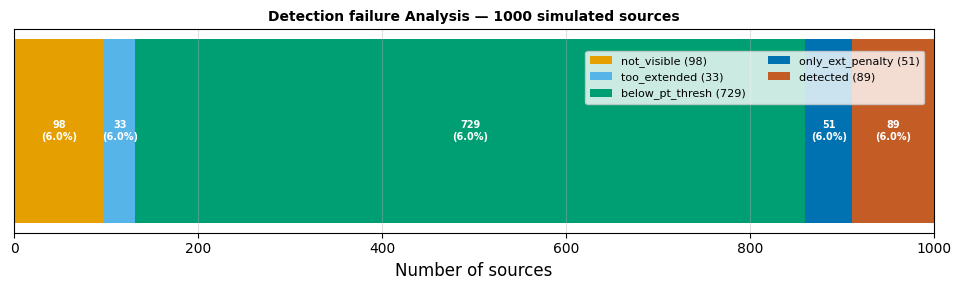

In [10]:
# Use the true source extents from the population model
true_extents = population["extent"]
breakdown = survey.get_detection_breakdown(
    population["coordinate"],
    population["flux"],
    true_extents,
)

labels = list(breakdown.keys())
counts = [int(v.sum()) for v in breakdown.values()]
pcts   = [100 * c / len(population) for c in counts]

fig, ax = plt.subplots(figsize=(10, 3))

colors = ["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#C45C26"]
left = 0
for lbl, cnt, color in zip(labels, counts, colors):
    ax.barh(0, cnt, left=left, color=color, label=f"{lbl} ({cnt})", height=0.5)
    if cnt > 15:
        ax.text(
            left + cnt / 2,
            0,
            f"{cnt}\n({pct:.1f}%)",
            ha="center",
            va="center",
            fontsize=7,
            fontweight="semibold",
            color="white",
        )
    left += cnt

ax.set_xlim(0, len(population))
ax.set_yticks([])
ax.set_xlabel("Number of sources", fontsize=12)
ax.set_title(
    f"Detection failure Analysis — {len(population)} simulated sources",
    fontsize=10, fontweight="semibold",
)
ax.legend(loc="upper left", bbox_to_anchor=(0.615, 0.92), fontsize=8, ncol=2, frameon=True,)
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.show()

## 8c. Sensitivity Scale Sweep

By varying sensitivity_scale we can ask: "at what threshold scaling does our simulated population give 78 detections?" 
This quantifies the offset between simulation and real survey.


Loops over **37 values** of `sensitivity_scale` from 0.2 to 2.0. For each value, creates a fresh `HGPS(sensitivity_scale=s)` instance and counts how many of the 1000 simulated sources would be detected. Plots the curve and marks:

- A horizontal dashed line at **78** — the number of sources in the published HGPS catalogue. (Based on the paper)
- A vertical marker at the `sensitivity_scale` value where the simulated count crosses 78.

This calibration tool quantifies us how far *the simulation's effective flux scale* is from what the real HGPS sensitivity map expects.

Again this is to find the `sensitivity_scale` that would reproduce 78 real HGPS detections. If the crossing happens at `scale ≈ 0.3–0.5`, the simulation is producing sources that are systematically fainter than what the real Galactic population needs to be — pointing to the luminosity function parameters. If the crossing is near `1.0`, the model is well-calibrated.


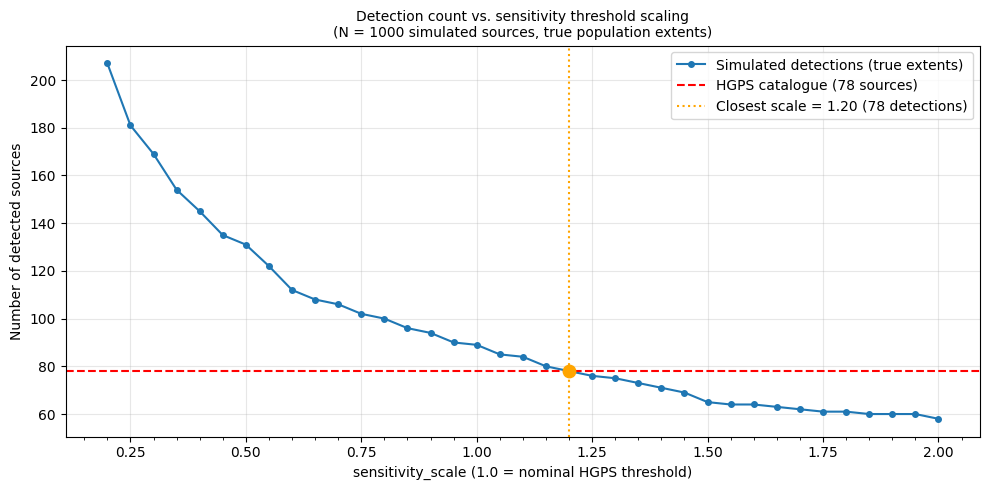


At sensitivity_scale = 1.20, model gives 78 detections (HESS Galactic Plane Survey = 78)


In [11]:
import matplotlib.ticker as ticker

HGPS_REAL_COUNT = 78  # Published HGPS catalogue source count

scales = np.linspace(0.2, 2.0, 37)   # from 20% to 200% of nominal threshold
true_extents = population["extent"]

detected_counts = []
for s in scales:
    surv_tmp = HGPS(sensitivity_scale=float(s))
    n = surv_tmp.is_detectable(
        population["coordinate"],
        population["flux"],
        true_extents,
    ).sum()
    detected_counts.append(int(n))

detected_counts = np.array(detected_counts)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(scales, detected_counts, "o-", color="#1f77b4", ms=4, lw=1.5,
        label="Simulated detections (true extents)")
ax.axhline(HGPS_REAL_COUNT, color="red", ls="--", lw=1.5,
           label=f"HGPS catalogue ({HGPS_REAL_COUNT} sources)")

# Mark crossing point (where simulated count ≈ real count)
crossing_idx = np.argmin(np.abs(detected_counts - HGPS_REAL_COUNT))
ax.axvline(scales[crossing_idx], color="orange", ls=":", lw=1.5,
           label=f"Closest scale = {scales[crossing_idx]:.2f} "
                 f"({detected_counts[crossing_idx]} detections)")
ax.scatter([scales[crossing_idx]], [detected_counts[crossing_idx]],
           color="orange", s=80, zorder=5)

ax.set_xlabel("sensitivity_scale (1.0 = nominal HGPS threshold)", fontsize=10)
ax.set_ylabel("Number of detected sources", fontsize=10)
ax.set_title(
    "Detection count vs. sensitivity threshold scaling\n"
    f"(N = {len(population)} simulated sources, true population extents)",
    fontsize=10, fontweight="light",
)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
plt.tight_layout()
plt.show()

print(f"\nAt sensitivity_scale = {scales[crossing_idx]:.2f}, "
      f"model gives {detected_counts[crossing_idx]} detections "
      f"(HESS Galactic Plane Survey = {HGPS_REAL_COUNT})")

### 8d. Visualize Detectable Sources (Method A)

Show which sources are detectable according to Method A for each extension assumption.

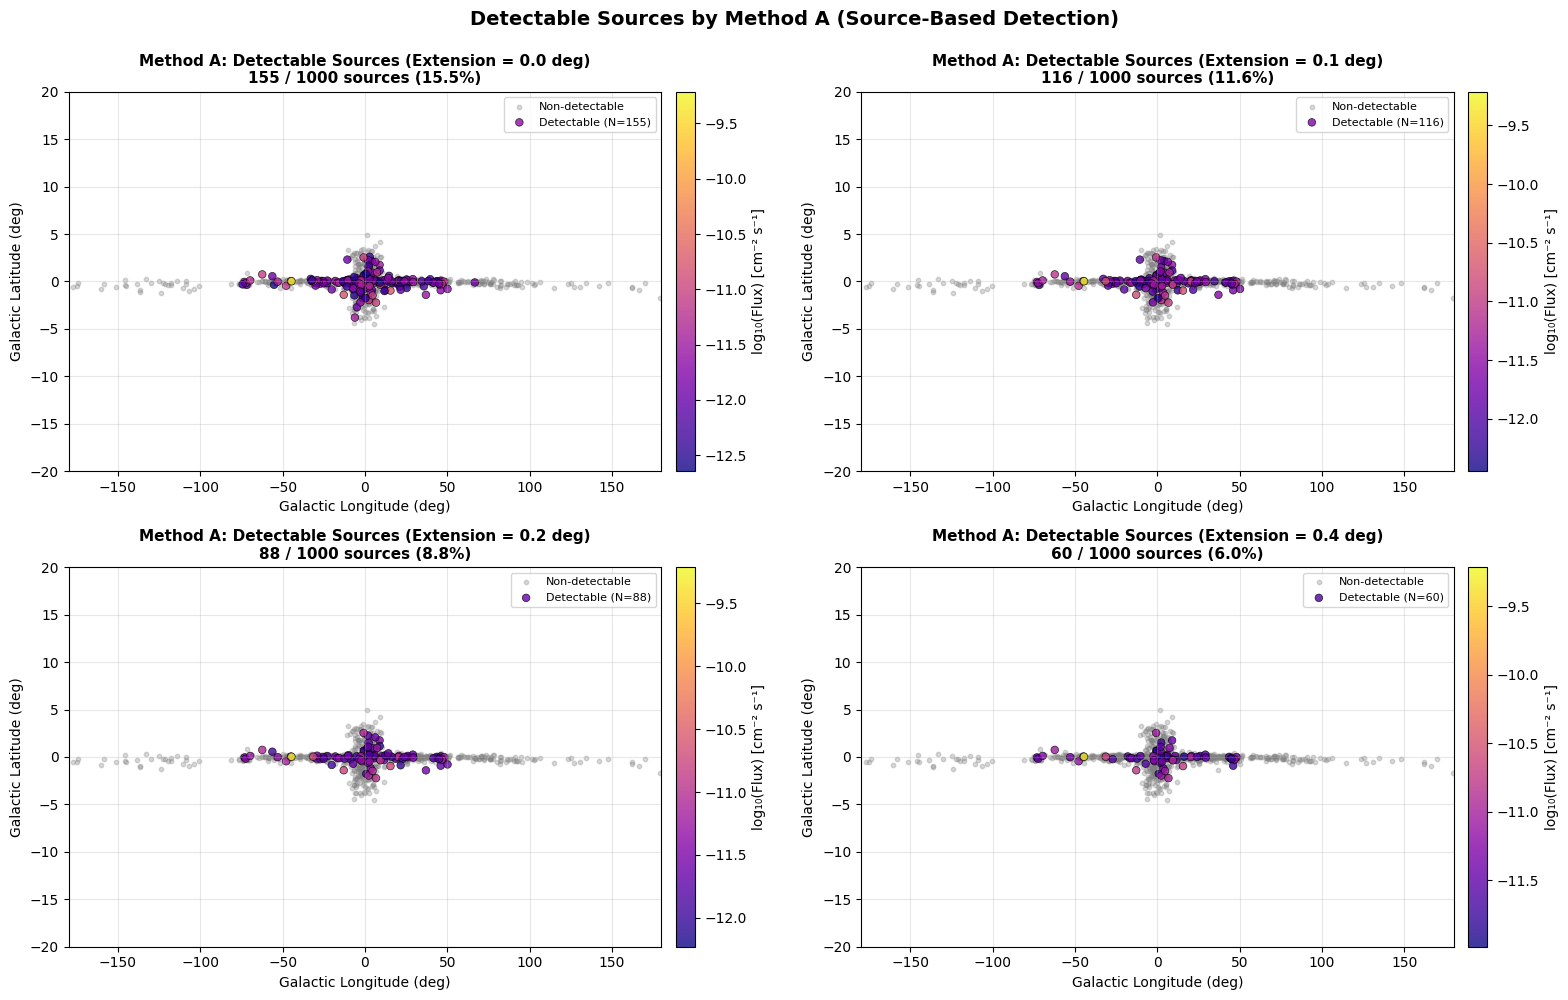

In [12]:
# Visualize detectable sources for each extension assumption
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, ext in enumerate(test_extensions):
    ax = axes[idx]
    
    # Assume all sources have this extension for Method A
    assumed_extents = np.full(len(population), ext.value) * u.deg
    
    # Get detectable sources
    detectable_mask = survey.is_detectable(
        population["coordinate"],
        population["flux"],
        assumed_extents
    )
    
    # Separate detectable and non-detectable sources
    detectable_coords = population[detectable_mask]["coordinate"]
    non_detectable_coords = population[~detectable_mask]["coordinate"]
    
    # Convert to Galactic coordinates and wrap at 180° for proper [-180, 180] range
    detectable_gal = detectable_coords.galactic
    non_detectable_gal = non_detectable_coords.galactic
    
    # Wrap longitude at 180° to get [-180, 180] range
    detectable_l = detectable_gal.l.wrap_at(180 * u.deg).deg
    #detectable_l = detectable_gal.l.deg
    non_detectable_l = non_detectable_gal.l.wrap_at(180 * u.deg).deg
    #non_detectable_l = non_detectable_gal.l.deg

    # Plot in Galactic coordinates
    # Non-detectable sources (gray)
    ax.scatter(non_detectable_l, non_detectable_gal.b.deg,
              s=10, alpha=0.3, c='gray', label='Non-detectable')
    
    # Detectable sources (colored by flux)
    if len(detectable_coords) > 0:
        scatter = ax.scatter(detectable_l, detectable_gal.b.deg,
                           s=30, alpha=0.8, 
                           c=np.log10(population[detectable_mask]["flux"].value),
                           cmap='plasma', edgecolors='black', linewidth=0.5,
                           label=f'Detectable (N={method_a_counts[ext.value]})')
        plt.colorbar(scatter, ax=ax, label='log₁₀(Flux) [cm⁻² s⁻¹]', pad=0.02)
    
    ax.set_xlabel('Galactic Longitude (deg)', fontsize=10)
    ax.set_ylabel('Galactic Latitude (deg)', fontsize=10)
    ax.set_title(f'Method A: Detectable Sources (Extension = {ext:.1f})\n'
                f'{method_a_counts[ext.value]} / {len(population)} sources ({100*method_a_counts[ext.value]/len(population):.1f}%)',
                fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xlim(-180, 180)  # Now shows full range: -180 to 180
    ax.set_ylim(-20, 20)

plt.suptitle('Detectable Sources by Method A (Source-Based Detection)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 9a. Method B: Map-Based Detection with Peak Finder

Applying peak finder function (Gammapy) to thresholded flux maps to count detected sources.

In [13]:
from gammapy.estimators.utils import find_peaks

# Peak finding parameters
# Use minimum distance based on PSF size
min_distance = 0.3 * u.deg  # Roughly 2x the PSF sigma

method_b_counts = {}
method_b_peaks = {}

print("\n METHOD B: Map-Based Detection with Peak Finder \n")
print(f"Peak finding parameters:")
print(f"  Minimum distance between peaks: {min_distance}")
print(f"  Threshold: 25th-percentile of surviving (non-zero) pixels per map\n")

for ext in test_extensions:
    # Get the thresholded flux map for this extension
    thresh_map = thresholded_flux_maps[ext.value]
    
    # Apply peak finder
    # Since the map is already thresholded, we just need to find local maxima
    try:
        # Get minimum non-zero value from the thresholded map
        non_zero_values = thresh_map.data[thresh_map.data > 0]
        
        if len(non_zero_values) > 0:
            # Use the 25th-percentile of surviving (non-zero) pixel values as the
            # peak threshold.  The old choice of 0.5 * min was essentially no
            # filter at all — almost every surviving pixel would pass it.
            # The 25th-percentile still keeps faint peaks but removes the very
            # lowest pixel noise at the edges of the sensitivity map footprint.
            # IMPORTANT: Pass as plain number (no units) to find_peaks.
            threshold_value = float(np.percentile(non_zero_values, 25))
            
            peaks = find_peaks(
                thresh_map,
                threshold=threshold_value,  # Pass without units
                min_distance=min_distance
            )
            
            n_peaks = len(peaks)
            method_b_counts[ext.value] = n_peaks
            method_b_peaks[ext.value] = peaks
            
            # For display, show threshold with units
            threshold_display = threshold_value * thresh_map.unit
            print(f"Extension {ext:.1f}: {n_peaks} peaks detected [threshold: {threshold_display:.2e}]")
        else:
            print(f"Extension {ext:.1f}: No detectable flux in map")
            method_b_counts[ext.value] = 0
            method_b_peaks[ext.value] = Table()
        
    except Exception as e:
        print(f"Extension {ext:.1f}: Error in peak finding - {str(e)}")
        method_b_counts[ext.value] = 0
        method_b_peaks[ext.value] = Table()


 METHOD B: Map-Based Detection with Peak Finder 

Peak finding parameters:
  Minimum distance between peaks: 0.3 deg
  Threshold: 25th-percentile of surviving (non-zero) pixels per map

Extension 0.0 deg: 25 peaks detected [threshold: 4.33e-13 1 / (s cm2)]
Extension 0.1 deg: 18 peaks detected [threshold: 5.85e-13 1 / (s cm2)]
Extension 0.2 deg: 11 peaks detected [threshold: 1.10e-12 1 / (s cm2)]
Extension 0.4 deg: 2 peaks detected [threshold: 1.84e-12 1 / (s cm2)]


### 9b. Visualize Detected Peaks for Each Extension

Show the detected peaks overlaid on thresholded flux maps.

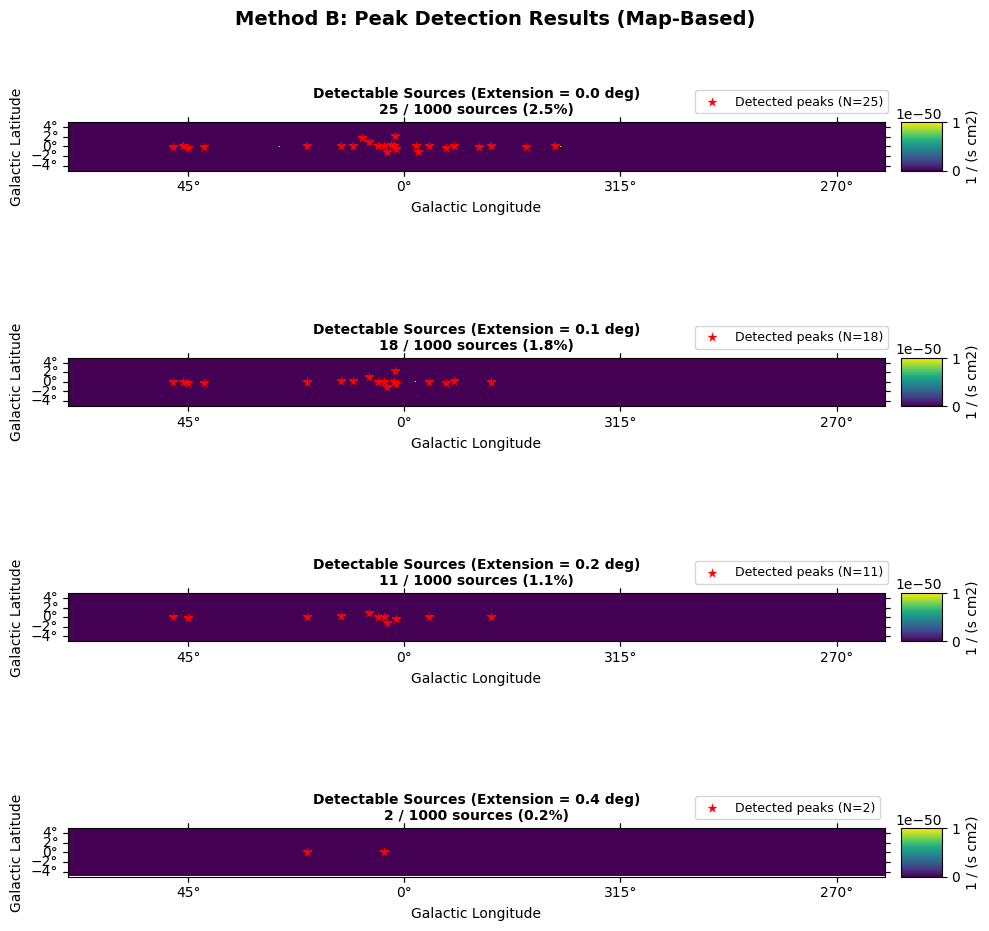

In [14]:
# Visualize peaks on thresholded maps in 2x2 grid
fig, axes = plt.subplots(4, 1, figsize=(10, 10),
                        subplot_kw={'projection': flux_map_2d.geom.wcs})
axes = axes.flatten()

# Plot each extension
for idx, ext in enumerate(test_extensions):
    ax = axes[idx]
    
    # Plot thresholded flux map
    #thresholded_flux_maps[ext.value].plot(ax=ax, add_cbar=True, cmap='viridis')

    thresholded_flux_maps[ext.value].plot(
    ax=ax, add_cbar=True, cmap='viridis',
    vmin=0, vmax=1e-50)  # set vmax to a value that fits your flux units
    
    # Overlay detected peaks
    peaks = method_b_peaks[ext.value]
    if len(peaks) > 0:
        peak_coords = SkyCoord(peaks['ra'], peaks['dec'], unit='deg', frame='icrs')
        peak_gal = peak_coords.galactic
        
        ax.scatter(
            peak_gal.l.deg, peak_gal.b.deg,
            transform=ax.get_transform('galactic'),
            s=50, marker='*', color='red', linewidths=0.1,
            label=f'Detected peaks (N={len(peaks)})'
        )
        #ax.legend(loc='upper right', fontsize=9)
        ax.legend(loc='upper left', bbox_to_anchor=(0.76, 1.8), fontsize=9)

    
    # Set title for each subplot with comparison
    #ax.set_title(f'Extension = {ext:.1f} \n'
               #f'Method B: {method_b_counts[ext.value]} peaks',
                #fontsize=10, fontweight='bold')

    ax.set_title(f'Detectable Sources (Extension = {ext:.1f})\n'
                f'{method_b_counts[ext.value]} / {len(population)} sources ({100*method_b_counts[ext.value]/len(population):.1f}%)',
                fontsize=10, fontweight='bold')
    
    ax.set_xlabel('Galactic Longitude', fontsize=10)
    ax.set_ylabel('Galactic Latitude', fontsize=10)

plt.suptitle('Method B: Peak Detection Results (Map-Based)', 
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 10. Method Comparison: 
### Source-Based vs. Map-Based Detection

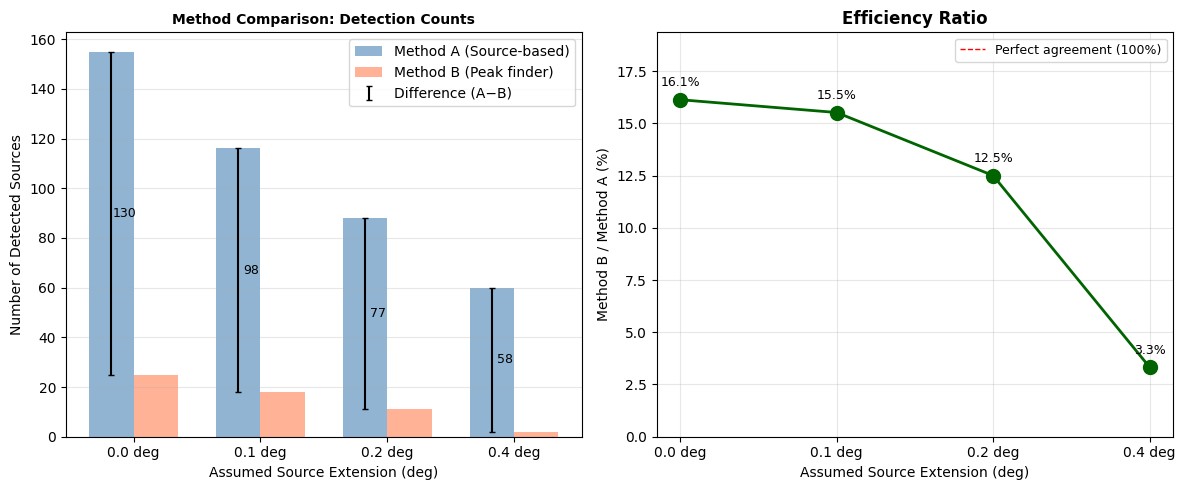


--------------------------------------------------------------------------------
Method Comparison Results
--------------------------------------------------------------------------------
Extension       Method A        Method B        Difference      Ratio (B/A)    
(deg)           (Sources)       (Peaks)         (A-B)           (%)            
--------------------------------------------------------------------------------
0.0             155             25              130             16.1           
0.1             116             18              98              15.5           
0.2             88              11              77              12.5           
0.4             60              2               58              3.3            
--------------------------------------------------------------------------------


In [15]:
# Create comparison plots (plot 1: counts with difference as error bars; plot 2: ratio)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

extensions_labels = [f"{ext:.1f}" for ext in test_extensions]
method_a_values = [method_a_counts[ext.value] for ext in test_extensions]
method_b_values = [method_b_counts[ext.value] for ext in test_extensions]
differences = [method_a_values[i] - method_b_values[i] for i in range(len(test_extensions))]

# Plot 1: Side-by-side bar comparison with detection count difference as error bars
x = np.arange(len(test_extensions))
width = 0.35

ax1 = axes[0]
bars1 = ax1.bar(x - width/2, method_a_values, width, label='Method A (Source-based)',
                color='steelblue', alpha=0.6)
bars2 = ax1.bar(x + width/2, method_b_values, width, label='Method B (Peak finder)',
                color='coral', alpha=0.6)

# Error bars on Method A: span from min(A,B) to max(A,B) (difference as error bar)
err_lower = [max(0, method_a_values[i] - method_b_values[i]) for i in range(len(test_extensions))]
err_upper = [max(0, method_b_values[i] - method_a_values[i]) for i in range(len(test_extensions))]
ax1.errorbar(x - width/2, method_a_values, yerr=[err_lower, err_upper], fmt='none',
             capsize=2, capthick=1.0, color='black', label='Difference (A−B)')

# Show difference count in the middle of each error bar
for i in range(len(test_extensions)):
    mid_y = (method_a_values[i] + method_b_values[i]) / 2
    ax1.text(x[i] - width/2 + 0.10, mid_y, f'{differences[i]:d}',
             ha='center', va='center', fontsize=9, fontweight='light')

ax1.legend(fontsize=10)
ax1.set_xlabel('Assumed Source Extension (deg)', fontsize=10)
ax1.set_ylabel('Number of Detected Sources', fontsize=10)
ax1.set_title('Method Comparison: Detection Counts', fontsize=10, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(extensions_labels)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)


# Plot 2: Ratio comparison
ax2 = axes[1]
ratios = [method_b_values[i] / method_a_values[i] * 100 if method_a_values[i] > 0 else 0
          for i in range(len(test_extensions))]

ax2.plot(extensions_labels, ratios, marker='o', markersize=10,
         linewidth=2, color='darkgreen')
ax2.axhline(y=100, color='red', linestyle='--', linewidth=1, label='Perfect agreement (100%)')
ax2.set_xlabel('Assumed Source Extension (deg)', fontsize=10)
ax2.set_ylabel('Method B / Method A (%)', fontsize=10)
ax2.set_title('Efficiency Ratio', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.legend(fontsize=9)
ax2.set_ylim(0, max(ratios) * 1.2 if ratios else 100)


# Add percentage labels
for i, (ratio, label) in enumerate(zip(ratios, extensions_labels)):
    ax2.text(i, ratio + 0.5, f'{ratio:.1f}%',
            ha='center', va='bottom', fontsize=9, fontweight='light')

plt.tight_layout()
plt.show()

# Summary table:
# Print detailed comparison table
print("\n" + "-"*80)
print("Method Comparison Results")
print("-"*80)

print(f"{'Extension':<15} {'Method A':<15} {'Method B':<15} {'Difference':<15} {'Ratio (B/A)':<15}")
print(f"{'(deg)':<15} {'(Sources)':<15} {'(Peaks)':<15} {'(A-B)':<15} {'(%)':<15}")
print("-" * 80)

for ext in test_extensions:
    method_a = method_a_counts[ext.value]
    method_b = method_b_counts[ext.value]
    diff = method_a - method_b
    ratio = (method_b / method_a * 100) if method_a > 0 else 0
    
    print(f"{ext.value:<15.1f} {method_a:<15} {method_b:<15} {diff:<15} {ratio:<15.1f}")
print("-" * 80)


## Summary: Method Comparison Results

**Key Observations:**

1. Average agreement between methods: 10-15% 
2. Method B detects FEWER sources than Method A
   Possible reasons:
   - Spatial blending: Multiple nearby sources appear as single peak
   - PSF convolution causes sources to merge in the map
   - Minimum distance parameter (0.3 deg) prevents detecting close sources

### Todo:
   1. Can we change the minimum distance?
      - If the min distance is lesser that 0.05 report several “peaks” inside one blurred source (noise / sub-structure) in Method B.

